Shear failure mode
Finished... Run Time =  3.999758005142212 sec
Finished... Run Time =  7.972980260848999 sec
Calibration Error:  0.05439294958555291  --- std:  0.04239572865244483
Surrogate Error:  0.22480650312125483  --- std:  0.15953926319884035
Surrogate-Calibration Error:  0.21548101907059405  --- std:  0.14928043259125362
No Model Error:  0.39897095554164846
1 - Model Error:  0.6010290444583515


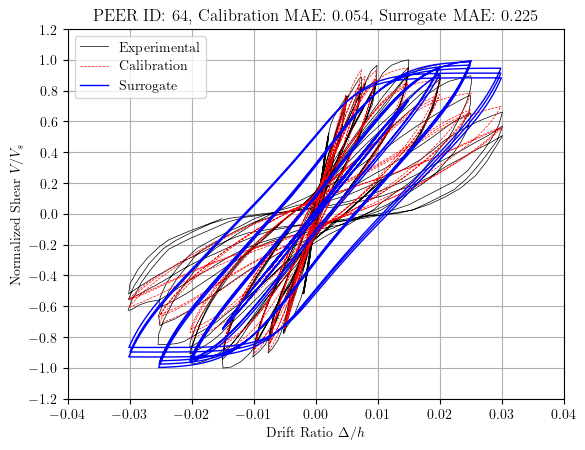

Flexure failure mode
Finished... Run Time =  6.8803606033325195 sec
Finished... Run Time =  6.897023916244507 sec
Calibration Error:  0.06334252641617248  --- std:  0.042819101251137665
Surrogate Error:  0.08474109365204627  --- std:  0.0667885915074454
Surrogate-Calibration Error:  0.05775760927067685  --- std:  0.04130626674021769
No Model Error:  0.34061376844172736
1 - Model Error:  0.6599220504558365


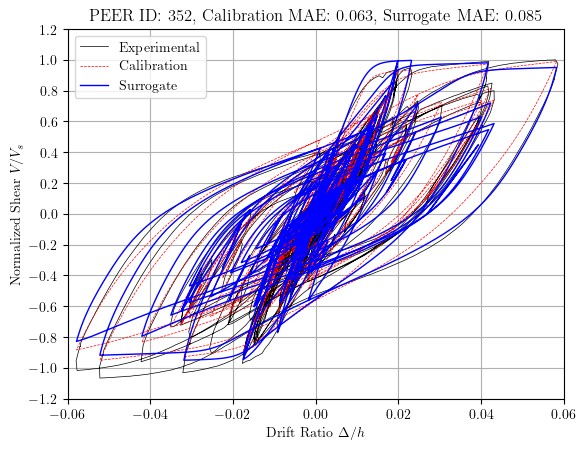

Flexure failure mode
Finished... Run Time =  3.284486770629883 sec
Finished... Run Time =  13.431482315063477 sec
Calibration Error:  0.07401394689325531  --- std:  0.062783389961807
Surrogate Error:  0.0885823334673901  --- std:  0.07387961811385942
Surrogate-Calibration Error:  0.03351769752673889  --- std:  0.0348112073505809
No Model Error:  0.43324961217510294
1 - Model Error:  0.5679551253263131


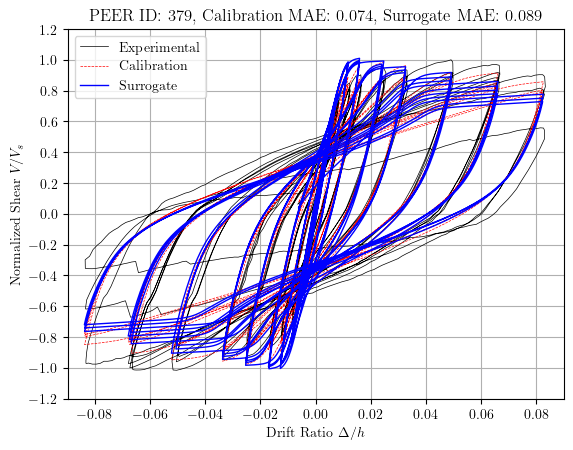

Flexure failure mode


KeyboardInterrupt: 

In [1]:
# Run surrogate predictions
from gpPredict import *
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import os

import pickle

from get_bw_params import *
from run_column_model import *


# Open calibration_info.csv

# Use latex for plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

calibration_info = pd.read_csv('calibration_info.csv')

# Open data_all.csv file
data_all = pd.read_csv('data_all.csv')

# Create a new dataframe to store the error metrics
error_metrics = pd.DataFrame(columns=['UniqueId', 'err_cal_exp', 'err_surr_exp', 'err_surr_cal', 'ar', 'lrr', 'srr', 'alr', 'sdr', 'smr'])


# Iterate over all rows in calibration_info
for ii in range(len(calibration_info)):
    # Get the UniqueId

    # *Task 1) Need to find whether it's in test or training dataset...
    UniqueId = calibration_info['UniqueId'].iloc[ii]

    # Find UniqueId in data_all
    row = data_all[data_all['UniqueId'] == UniqueId]

    # For this row, get the calibrated bw model parameters
    calParams = calibration_info[['gamma', 'kappa', 'eta1', 'sig', 'lam', 'mup', 'sigp', 'rsmax', 'alpha', 'alpha1', 'alpha2', 'betam1', 'n', 'kappa_k']].iloc[ii].values

    # Now, from data_all, get the nondimensional parameters
    ndParams = row[['ar', 'lrr', 'srr', 'alr', 'sdr', 'smr']].values[0]

    # Get surrogate-predicted bw model parameters
    predParams, predErr, failureMode = get_BW_params(ndParams)

    # Get the test_XXX.json file from test_data folder where XXX is the UniqueId
    with open('test_data/test_' + str(UniqueId).zfill(3) + '.json') as f:
        test_data = json.load(f)

    # Run the column model with the calParams
    calResults = run_model(test_data, calParams, do_plots=False)

    # Run the column model with the predParams
    surrResults = run_model(test_data, predParams, do_plots=False)

    print('Calibration Error: ', calResults['err_data']['mean_err'], ' --- std: ', calResults['err_data']['std_err'])
    print('Surrogate Error: ', surrResults['err_data']['mean_err'], ' --- std: ', surrResults['err_data']['std_err'])

    # Calculate difference between surrogate and calibration
    err_surr_cal = np.mean(np.abs(np.array(surrResults['sim_data']['nforce']) - np.array(calResults['sim_data']['nforce'])))
    std_surr_cal = np.std(np.abs(np.array(surrResults['sim_data']['nforce']) - np.array(calResults['sim_data']['nforce'])))

    print('Surrogate-Calibration Error: ', err_surr_cal, ' --- std: ', std_surr_cal)
    print('No Model Error: ', surrResults['err_data']['no_model_err'])
    print('1 - Model Error: ', surrResults['err_data']['one_model_err'])

    plt.figure()
    # Plot experimental data
    plt.plot(calResults['exp_data']['drift'], calResults['exp_data']['nforce'], label='Experimental', color='black', linewidth=0.5)
    # Plot from calResults drift vs normalized force
    plt.plot(calResults['sim_data']['drift'], calResults['sim_data']['nforce'], label='Calibration', color='red', linewidth=0.5, linestyle='--')
    # Plot from surrResults displacement vs normalized force
    plt.plot(surrResults['sim_data']['drift'], surrResults['sim_data']['nforce'], label='Surrogate', color='blue', linewidth=1.0, linestyle='-')
    plt.xlabel('Drift Ratio $\Delta/h$')
    plt.ylabel('Normalized Shear $V/V_s$')
    plt.legend()
    plt.title('PEER ID: ' + str(UniqueId) + ', Calibration MAE: ' + 
              format(calResults['err_data']['mean_err'], '.3f') + 
              ', Surrogate MAE: ' + format(surrResults['err_data']['mean_err'], '.3f'))
    # Set ylim
    plt.ylim([-1.2, 1.2])
    # Set yticks to be in increments of 0.2 from -1.2 to 1.2
    plt.yticks(np.arange(-1.2, 1.3, 0.2))
    # Set xlim to be between min and max of the drift in the experimental data
    
    xlims = [np.floor(min(calResults['exp_data']['drift']) * 100) / 100, 
             np.ceil(max(calResults['exp_data']['drift']) * 100) / 100]
    # Get the limits from the experimental data for x-axis
    plt.xlim(xlims) # Set the x-limits based on the experimental data

    # Add grid
    plt.grid()
    # Save the figure to a file
    plt.savefig(os.path.join('surrogate_plots', f'UniqueId_{str(UniqueId).zfill(3)}_cal_vs_surr.pdf'))
    plt.show()

    # Append to error_metrics dataframe
    error_metrics = error_metrics.append(
        {
            'UniqueId': UniqueId, 
            'err_cal_exp': calResults['err_data']['mean_err'],
            'err_surr_exp': surrResults['err_data']['mean_err'],
            'no_model_err': surrResults['err_data']['no_model_err'],
            'one_model_err': surrResults['err_data']['one_model_err'],
            'err_surr_cal': err_surr_cal,
            'ar': ndParams[0],
            'lrr': ndParams[1],
            'srr': ndParams[2],
            'alr': ndParams[3],
            'sdr': ndParams[4],
            'smr': ndParams[5],
            'ColumnType': row['Type'].values[0],
            'FailureMode': row['FailureType'].values[0]
        }, ignore_index=True)

# Save error_metrics to a csv file
error_metrics.to_csv('error_metrics.csv', index=False)
